## Exploratory Data Analysis (EDA) notebook - LCL电力数据集

### 本notebook用于探索LCL-June2015v2_0.csv电力消耗数据集，分析其统计特征、时间序列模式和客户用电行为

In [1]:
import os

import copy

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import colorcet as cc

import warnings
warnings.filterwarnings("ignore")

In [2]:
sns.set_style('darkgrid')
sns.set(rc={'figure.figsize':(14,8)})

### 加载LCL电力数据集
数据集包含多个客户的每半小时用电量数据（KWH/hh）

In [3]:
# 加载LCL电力数据集
data_path = "../CBL-dataset/LCL-June2015v2_0.csv"
print(f"正在加载数据集: {data_path}")

正在加载数据集: ../CBL-dataset/LCL-June2015v2_0.csv


In [4]:
# 读取CSV文件，注意列名中有空格
df = pd.read_csv(data_path)
print(f"数据集形状: {df.shape}")
print(f"列名: {df.columns.tolist()}")
df.head()

数据集形状: (1000000, 4)
列名: ['LCLid', 'stdorToU', 'DateTime', 'KWH/hh (per half hour) ']


,LCLid,stdorToU,DateTime,KWH/hh (per half hour)
0,MAC000002,Std,2012-10-12 00:30:00.0000000,0
1,MAC000002,Std,2012-10-12 01:00:00.0000000,0
2,MAC000002,Std,2012-10-12 01:30:00.0000000,0
3,MAC000002,Std,2012-10-12 02:00:00.0000000,0
4,MAC000002,Std,2012-10-12 02:30:00.0000000,0


In [5]:
# 清理列名（去除空格）
df.columns = df.columns.str.strip()
print("清理后的列名:", df.columns.tolist())

# 重命名列以便于使用
df = df.rename(columns={
    'LCLid': 'customer_id',
    'stdorToU': 'tariff_type',
    'DateTime': 'datetime',
    'KWH/hh (per half hour)': 'kwh'
})

# 转换数据类型
df['datetime'] = pd.to_datetime(df['datetime'], format="%Y-%m-%d %H:%M:%S.%f", errors='coerce')
df['kwh'] = pd.to_numeric(df['kwh'], errors='coerce')

# 显示基本信息
print(f"\n数据集基本信息:")
print(f"总行数: {len(df):,}")
print(f"唯一客户数: {df['customer_id'].nunique()}")
print(f"时间范围: {df['datetime'].min()} 到 {df['datetime'].max()}")
print(f"\n数据类型:")
print(df.dtypes)
print(f"\n缺失值统计:")
print(df.isnull().sum())

清理后的列名: ['LCLid', 'stdorToU', 'DateTime', 'KWH/hh (per half hour)']

数据集基本信息:
总行数: 1,000,000
唯一客户数: 30
时间范围: 2011-12-06 13:00:00 到 2014-02-28 00:00:00

数据类型:
customer_id            object
tariff_type            object
datetime       datetime64[ns]
kwh                   float64
dtype: object

缺失值统计:
customer_id     0
tariff_type     0
datetime        0
kwh            29
dtype: int64


In [7]:
# 时间范围详细分析
print("时间范围分析:")
print(f"最早时间: {df['datetime'].min()}")
print(f"最晚时间: {df['datetime'].max()}")
print(f"时间跨度: {df['datetime'].max() - df['datetime'].min()}")

# 按客户统计时间范围
print("\n各客户的时间范围:")
customer_time_ranges = df.groupby('customer_id')['datetime'].agg(['min', 'max', 'count'])
print(customer_time_ranges.head(30))

时间范围分析:
最早时间: 2011-12-06 13:00:00
最晚时间: 2014-02-28 00:00:00
时间跨度: 814 days 11:00:00

各客户的时间范围:
                            min                 max  count
customer_id                                               
MAC000002   2012-10-12 00:30:00 2014-02-28 00:00:00  24158
MAC000003   2012-02-20 13:00:00 2014-02-28 00:00:00  35469
MAC000004   2012-05-08 13:00:00 2014-02-28 00:00:00  31677
MAC000006   2012-01-30 11:30:00 2014-02-28 00:00:00  36461
MAC000007   2012-09-24 12:00:00 2014-02-28 00:00:00  25046
MAC000008   2012-05-05 09:00:00 2013-10-30 00:00:00  26013
MAC000009   2012-09-20 10:00:00 2014-02-28 00:00:00  25238
MAC000010   2012-09-24 12:30:00 2014-02-28 00:00:00  25049
MAC000011   2012-10-22 11:00:00 2014-02-28 00:00:00  23705
MAC000012   2012-10-02 09:30:00 2014-02-28 00:00:00  24670
MAC000013   2012-06-21 07:30:00 2014-02-28 00:00:00  29614
MAC000016   2011-12-06 13:00:00 2013-01-16 00:00:00  19524
MAC000018   2011-12-07 09:30:00 2014-02-28 00:00:00  39082
MAC000019   2011-12-

In [8]:
# 创建时间特征
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['dayofyear'] = df['datetime'].dt.dayofyear
df['week'] = df['datetime'].dt.isocalendar().week

# 显示前几行
df.head(10)

,customer_id,tariff_type,datetime,kwh,year,month,day,hour,dayofweek,dayofyear,week
0,MAC000002,Std,2012-10-12 00:30:00,0.0,2012,10,12,0,4,286,41
1,MAC000002,Std,2012-10-12 01:00:00,0.0,2012,10,12,1,4,286,41
2,MAC000002,Std,2012-10-12 01:30:00,0.0,2012,10,12,1,4,286,41
3,MAC000002,Std,2012-10-12 02:00:00,0.0,2012,10,12,2,4,286,41
4,MAC000002,Std,2012-10-12 02:30:00,0.0,2012,10,12,2,4,286,41
5,MAC000002,Std,2012-10-12 03:00:00,0.0,2012,10,12,3,4,286,41
6,MAC000002,Std,2012-10-12 03:30:00,0.0,2012,10,12,3,4,286,41
7,MAC000002,Std,2012-10-12 04:00:00,0.0,2012,10,12,4,4,286,41
8,MAC000002,Std,2012-10-12 04:30:00,0.0,2012,10,12,4,4,286,41
9,MAC000002,Std,2012-10-12 05:00:00,0.0,2012,10,12,5,4,286,41


### 数据集基本统计信息

In [9]:
# 基本统计信息
print("数据集形状:", df.shape)
print("\n用电量(kwh)统计:")
print(df['kwh'].describe())
print(f"\n用电量统计详情:")
print(f"最小值: {df['kwh'].min():.4f}")
print(f"最大值: {df['kwh'].max():.4f}")
print(f"平均值: {df['kwh'].mean():.4f}")
print(f"中位数: {df['kwh'].median():.4f}")
print(f"标准差: {df['kwh'].std():.4f}")
print(f"偏度: {df['kwh'].skew():.4f}")
print(f"峰度: {df['kwh'].kurtosis():.4f}")

数据集形状: (1000000, 11)

用电量(kwh)统计:
count    999971.000000
mean          0.239580
std           0.387533
min           0.000000
25%           0.060000
50%           0.129000
75%           0.255000
max           6.528000
Name: kwh, dtype: float64

用电量统计详情:
最小值: 0.0000
最大值: 6.5280
平均值: 0.2396
中位数: 0.1290
标准差: 0.3875
偏度: 5.8497
峰度: 53.5584


In [10]:
# 查看前几行数据
df.head(10)

,customer_id,tariff_type,datetime,kwh,year,month,day,hour,dayofweek,dayofyear,week
0,MAC000002,Std,2012-10-12 00:30:00,0.0,2012,10,12,0,4,286,41
1,MAC000002,Std,2012-10-12 01:00:00,0.0,2012,10,12,1,4,286,41
2,MAC000002,Std,2012-10-12 01:30:00,0.0,2012,10,12,1,4,286,41
3,MAC000002,Std,2012-10-12 02:00:00,0.0,2012,10,12,2,4,286,41
4,MAC000002,Std,2012-10-12 02:30:00,0.0,2012,10,12,2,4,286,41
5,MAC000002,Std,2012-10-12 03:00:00,0.0,2012,10,12,3,4,286,41
6,MAC000002,Std,2012-10-12 03:30:00,0.0,2012,10,12,3,4,286,41
7,MAC000002,Std,2012-10-12 04:00:00,0.0,2012,10,12,4,4,286,41
8,MAC000002,Std,2012-10-12 04:30:00,0.0,2012,10,12,4,4,286,41
9,MAC000002,Std,2012-10-12 05:00:00,0.0,2012,10,12,5,4,286,41


In [11]:
# 按客户统计
print("客户统计信息:")
print(f"总客户数: {df['customer_id'].nunique()}")
print(f"\n每个客户的数据点数量:")
customer_counts = df['customer_id'].value_counts()
print(customer_counts.describe())
print(f"\n前10个客户的数据点数量:")
print(customer_counts.head(10))

客户统计信息:
总客户数: 30

每个客户的数据点数量:
count       30.000000
mean     33333.333333
std       7314.262997
min      16175.000000
25%      25431.750000
50%      39025.500000
75%      39069.000000
max      39082.000000
Name: count, dtype: float64

前10个客户的数据点数量:
customer_id
MAC000018    39082
MAC000020    39079
MAC000021    39079
MAC000022    39072
MAC000033    39071
MAC000019    39071
MAC000034    39070
MAC000023    39069
MAC000032    39069
MAC000027    39069
Name: count, dtype: int64


In [12]:
# 电价类型统计
print("电价类型统计:")
print(df['tariff_type'].value_counts())
print(f"\n各电价类型的用电量统计:")
print(df.groupby('tariff_type')['kwh'].describe())

电价类型统计:
tariff_type
Std    1000000
Name: count, dtype: int64

各电价类型的用电量统计:
                count     mean       std  min   25%    50%    75%    max
tariff_type                                                             
Std          999971.0  0.23958  0.387533  0.0  0.06  0.129  0.255  6.528


### 用电量分布分析

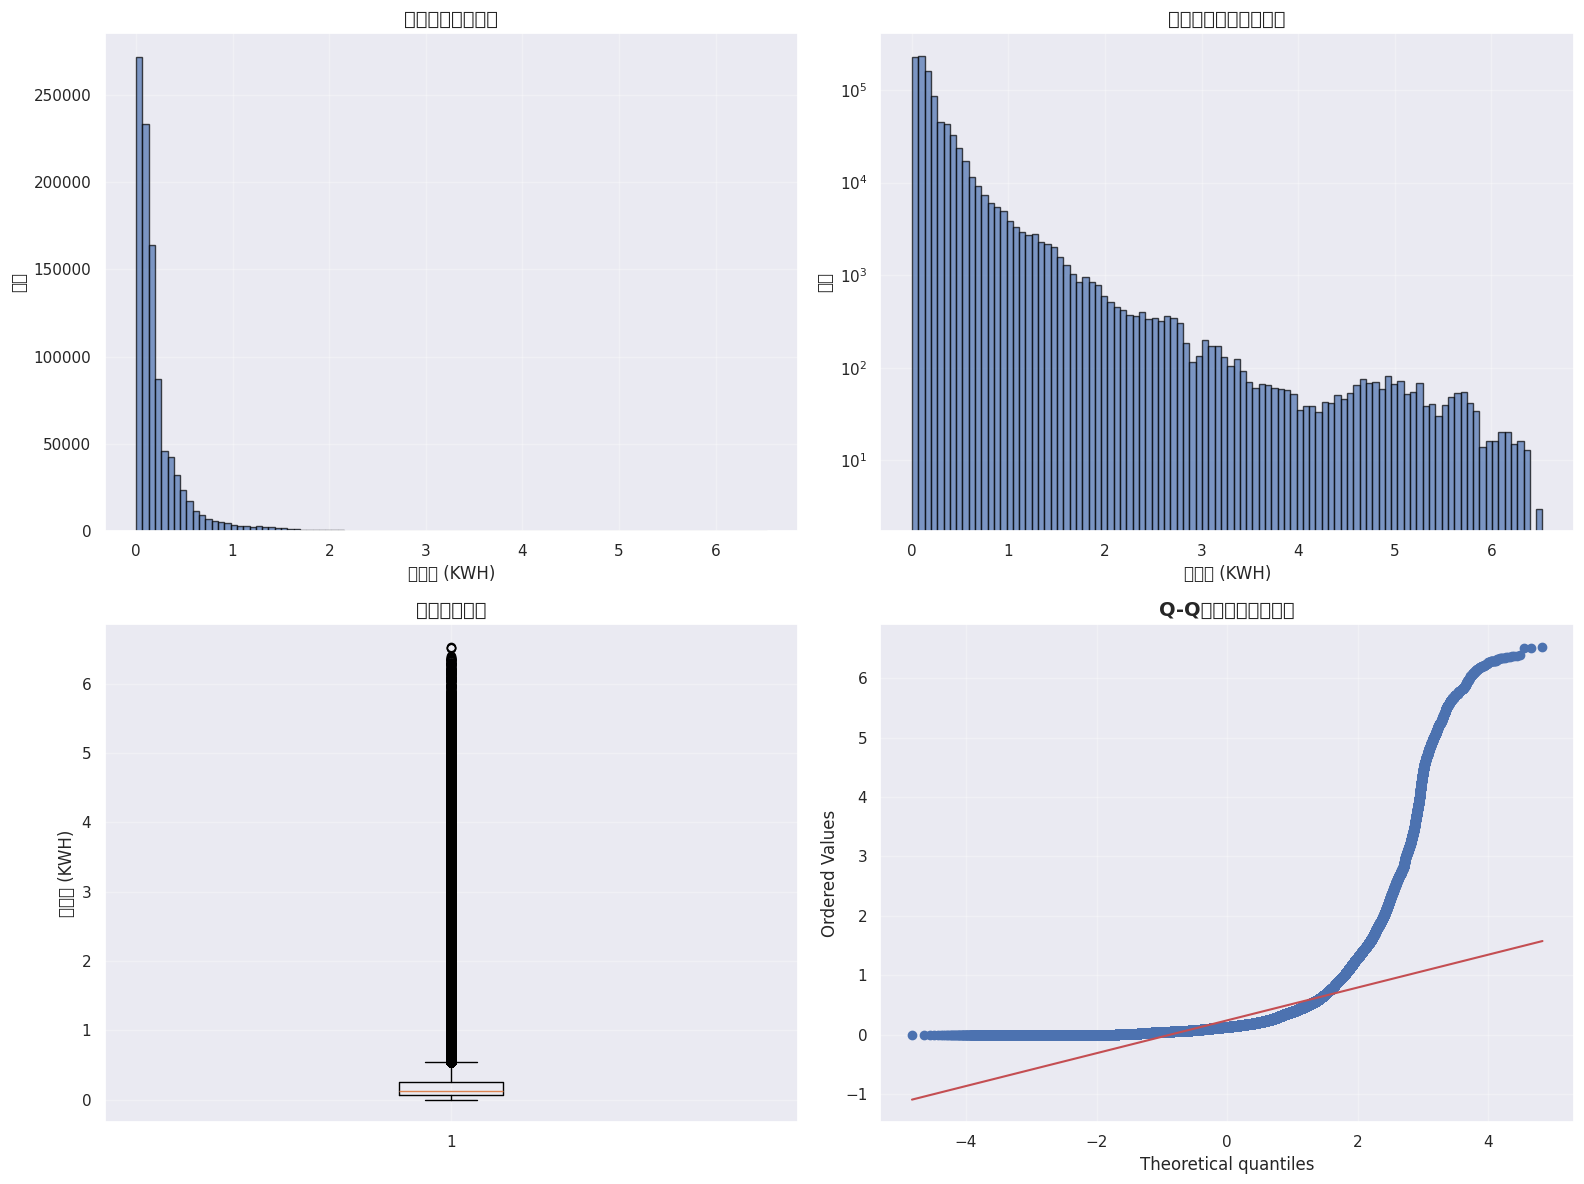

In [13]:
# 用电量分布可视化
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 直方图
axes[0, 0].hist(df['kwh'].dropna(), bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('用电量 (KWH)', fontsize=12)
axes[0, 0].set_ylabel('频数', fontsize=12)
axes[0, 0].set_title('用电量分布直方图', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. 对数尺度直方图（处理长尾分布）
axes[0, 1].hist(df[df['kwh'] > 0]['kwh'], bins=100, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('用电量 (KWH)', fontsize=12)
axes[0, 1].set_ylabel('频数', fontsize=12)
axes[0, 1].set_title('用电量分布（仅正数）', fontsize=14, fontweight='bold')
axes[0, 1].set_yscale('log')
axes[0, 1].grid(True, alpha=0.3)

# 3. 箱线图
axes[1, 0].boxplot(df['kwh'].dropna(), vert=True)
axes[1, 0].set_ylabel('用电量 (KWH)', fontsize=12)
axes[1, 0].set_title('用电量箱线图', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Q-Q图（检查正态性）
from scipy import stats
stats.probplot(df['kwh'].dropna(), dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q图（正态性检验）', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# 按客户统计用电量
print("按客户统计用电量:")
customer_stats = df.groupby('customer_id')['kwh'].agg(['min', 'max', 'mean', 'median', 'std', 'count'])
print(customer_stats.describe())
print(f"\n前10个客户的用电量统计:")
print(customer_stats.head(10))

按客户统计用电量:
             min        max       mean     median        std         count
count  30.000000  30.000000  30.000000  30.000000  30.000000     30.000000
mean    0.025300   2.557733   0.232047   0.145867   0.253349  33332.366667
std     0.032186   1.379922   0.156590   0.108405   0.230203   7314.182107
min     0.000000   0.505000   0.027351   0.000000   0.052547  16175.000000
25%     0.000000   1.645000   0.102663   0.065250   0.110665  25430.750000
50%     0.015500   2.450000   0.210829   0.134500   0.204388  39024.500000
75%     0.028500   3.309500   0.310390   0.165250   0.288993  39068.000000
max     0.113000   6.528000   0.566821   0.410000   1.140982  39081.000000

前10个客户的用电量统计:
               min    max      mean  median       std  count
customer_id                                                 
MAC000002    0.000  2.994  0.252562   0.158  0.247123  24157
MAC000003    0.007  3.921  0.397666   0.166  0.615261  35468
MAC000004    0.000  1.065  0.035383   0.000  0.073146  3

### 时间序列可视化

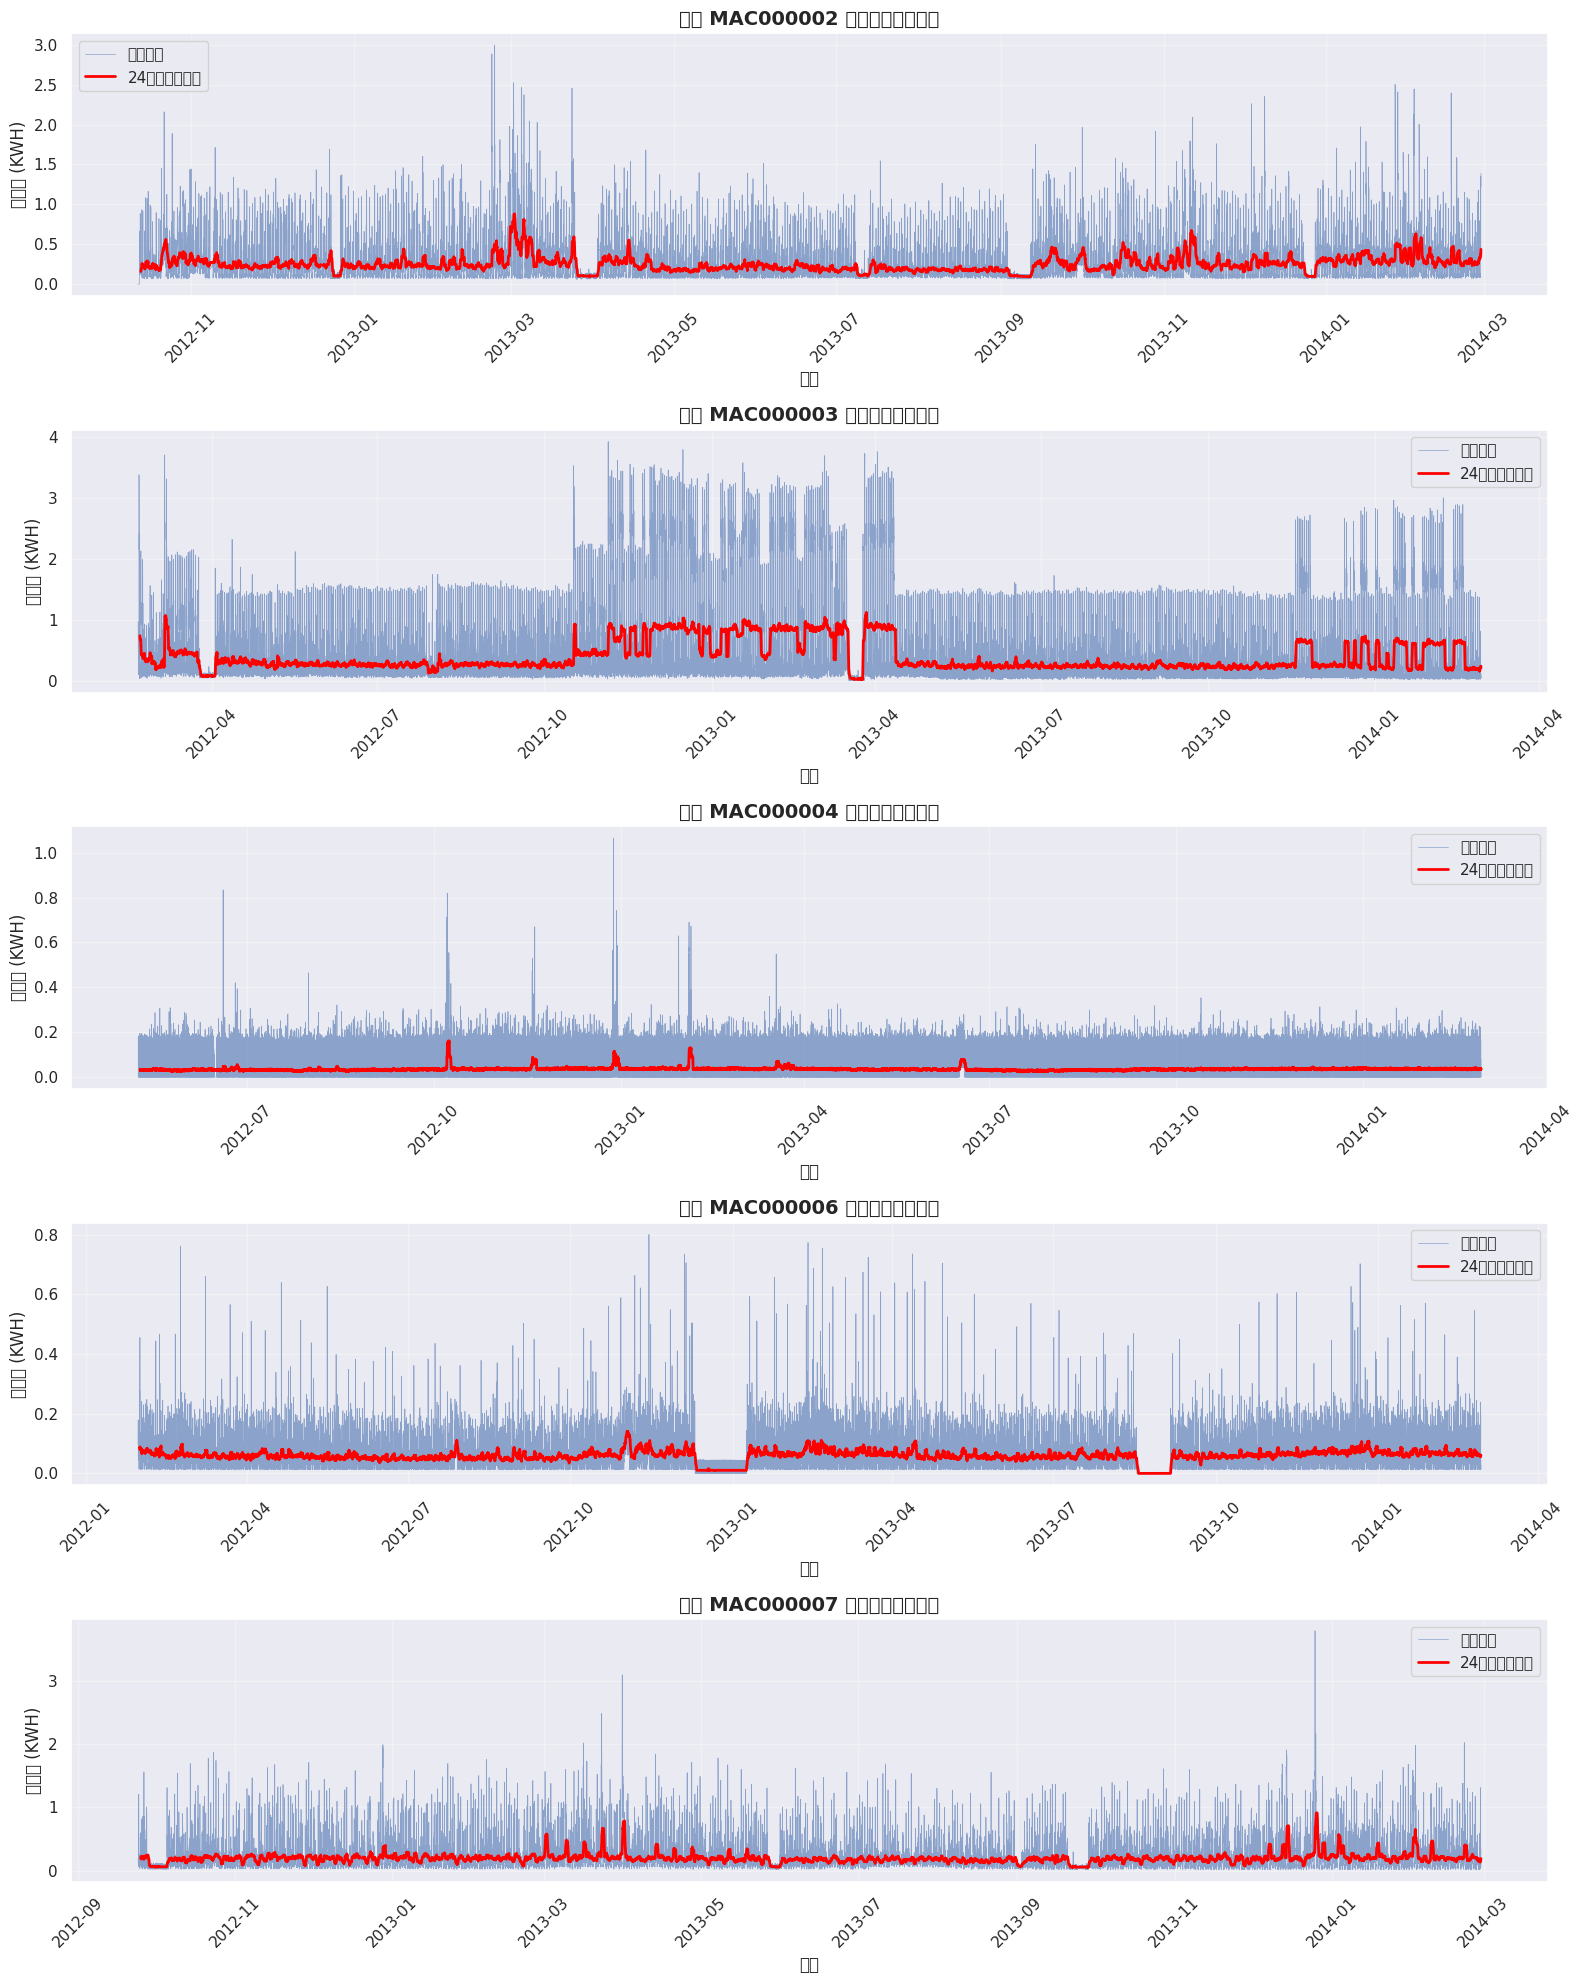

In [15]:
# 选择几个代表性客户进行时间序列可视化
sample_customers = df['customer_id'].unique()[:5]  # 选择前5个客户

fig, axes = plt.subplots(len(sample_customers), 1, figsize=(16, 4*len(sample_customers)))
if len(sample_customers) == 1:
    axes = [axes]

for idx, customer in enumerate(sample_customers):
    customer_data = df[df['customer_id'] == customer].sort_values('datetime')
    customer_data = customer_data.set_index('datetime')
    
    # 绘制原始数据
    axes[idx].plot(customer_data.index, customer_data['kwh'], alpha=0.6, linewidth=0.5, label='原始数据')
    
    # 绘制移动平均
    rolling_mean = customer_data['kwh'].rolling(window=48).mean()  # 24小时移动平均（48个半小时）
    axes[idx].plot(rolling_mean.index, rolling_mean.values, linewidth=2, label='24小时移动平均', color='red')
    
    axes[idx].set_xlabel('时间', fontsize=12)
    axes[idx].set_ylabel('用电量 (KWH)', fontsize=12)
    axes[idx].set_title(f'客户 {customer} 的用电量时间序列', fontsize=14, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

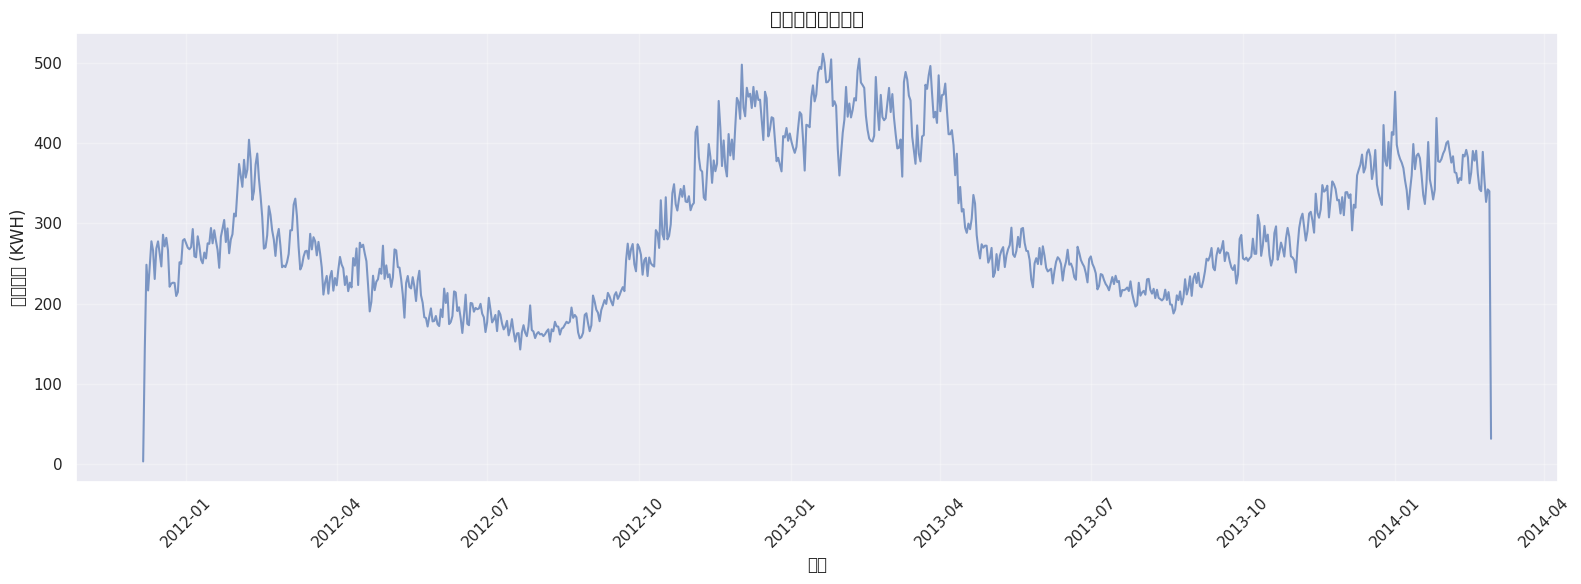

In [16]:
# 整体用电量趋势（按日期聚合）
daily_consumption = df.groupby(df['datetime'].dt.date)['kwh'].sum()

plt.figure(figsize=(16, 6))
plt.plot(daily_consumption.index, daily_consumption.values, linewidth=1.5, alpha=0.7)
plt.xlabel('日期', fontsize=12)
plt.ylabel('总用电量 (KWH)', fontsize=12)
plt.title('每日总用电量趋势', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 按小时的平均用电量分析

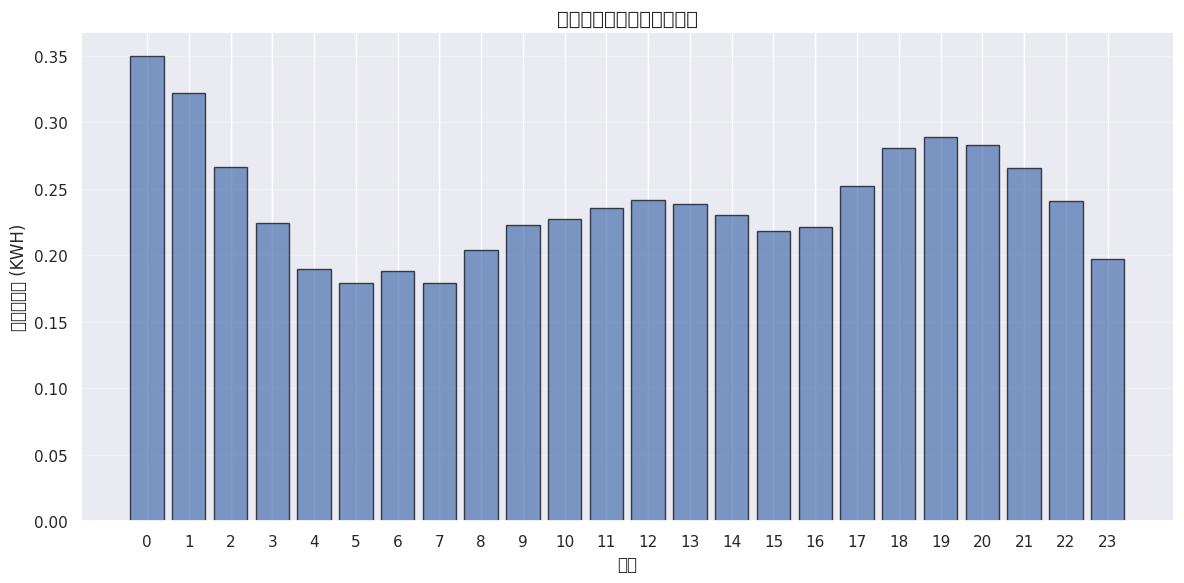

每小时平均用电量:
hour
0     0.350233
1     0.322319
2     0.266656
3     0.224086
4     0.189768
5     0.179395
6     0.188437
7     0.179425
8     0.203655
9     0.222750
10    0.227093
11    0.235603
12    0.241874
13    0.238646
14    0.230154
15    0.218509
16    0.221438
17    0.252210
18    0.280706
19    0.288996
20    0.282805
21    0.265482
22    0.240516
23    0.197155
Name: kwh, dtype: float64


In [17]:
# 按小时统计平均用电量
hourly_avg = df.groupby('hour')['kwh'].mean()

plt.figure(figsize=(12, 6))
plt.bar(hourly_avg.index, hourly_avg.values, alpha=0.7, edgecolor='black')
plt.xlabel('小时', fontsize=12)
plt.ylabel('平均用电量 (KWH)', fontsize=12)
plt.title('一天中每小时的平均用电量', fontsize=14, fontweight='bold')
plt.xticks(range(24))
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("每小时平均用电量:")
print(hourly_avg)

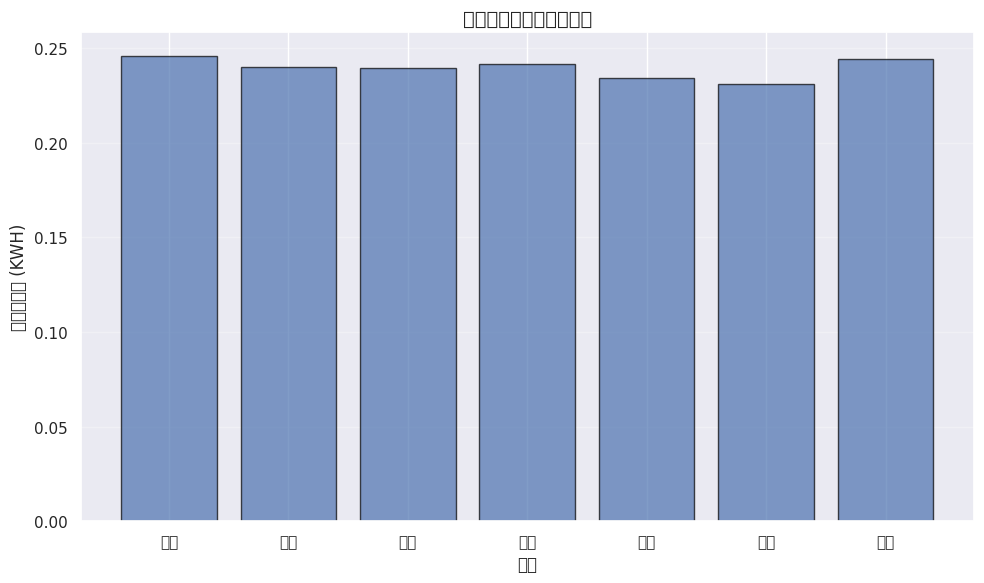

每周平均用电量:
周一: 0.2461 KWH
周二: 0.2400 KWH
周三: 0.2396 KWH
周四: 0.2415 KWH
周五: 0.2342 KWH
周六: 0.2310 KWH
周日: 0.2446 KWH


In [18]:
# 按星期几统计平均用电量
day_names = ['周一', '周二', '周三', '周四', '周五', '周六', '周日']
weekly_avg = df.groupby('dayofweek')['kwh'].mean()

plt.figure(figsize=(10, 6))
plt.bar(range(7), weekly_avg.values, alpha=0.7, edgecolor='black')
plt.xlabel('星期', fontsize=12)
plt.ylabel('平均用电量 (KWH)', fontsize=12)
plt.title('一周中每天的平均用电量', fontsize=14, fontweight='bold')
plt.xticks(range(7), day_names)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("每周平均用电量:")
for i, day in enumerate(day_names):
    print(f"{day}: {weekly_avg.iloc[i]:.4f} KWH")

### 季节性箱线图分析
箱线图用于展示数据的分布、中位数、四分位数和异常值。我们按小时创建箱线图来分析用电量的统计特征。

In [19]:
def seasonal_box_plot(df, column, group_by='hour', title=''):
    """创建季节性箱线图"""
    fig, ax = plt.subplots(figsize=(14, 6))
    
    sns.boxplot(x=df[group_by], y=df[column], ax=ax)
    ax.set_title(title if title else f'按{group_by}的用电量分布', 
                 fontsize=16, fontweight='bold')
    ax.set_xlabel(group_by, fontsize=14, fontweight='bold')
    ax.set_ylabel('用电量 (KWH)', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    plt.close()

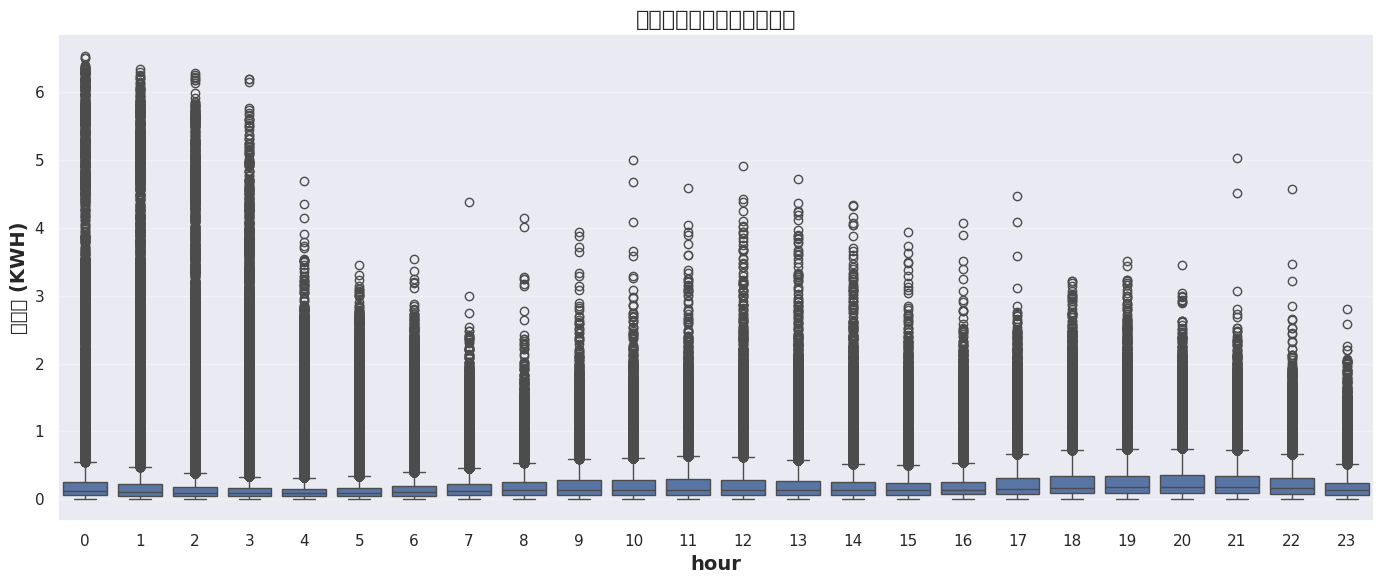

In [20]:
# 按小时的箱线图
seasonal_box_plot(df, 'kwh', group_by='hour', title='按小时的用电量分布箱线图')

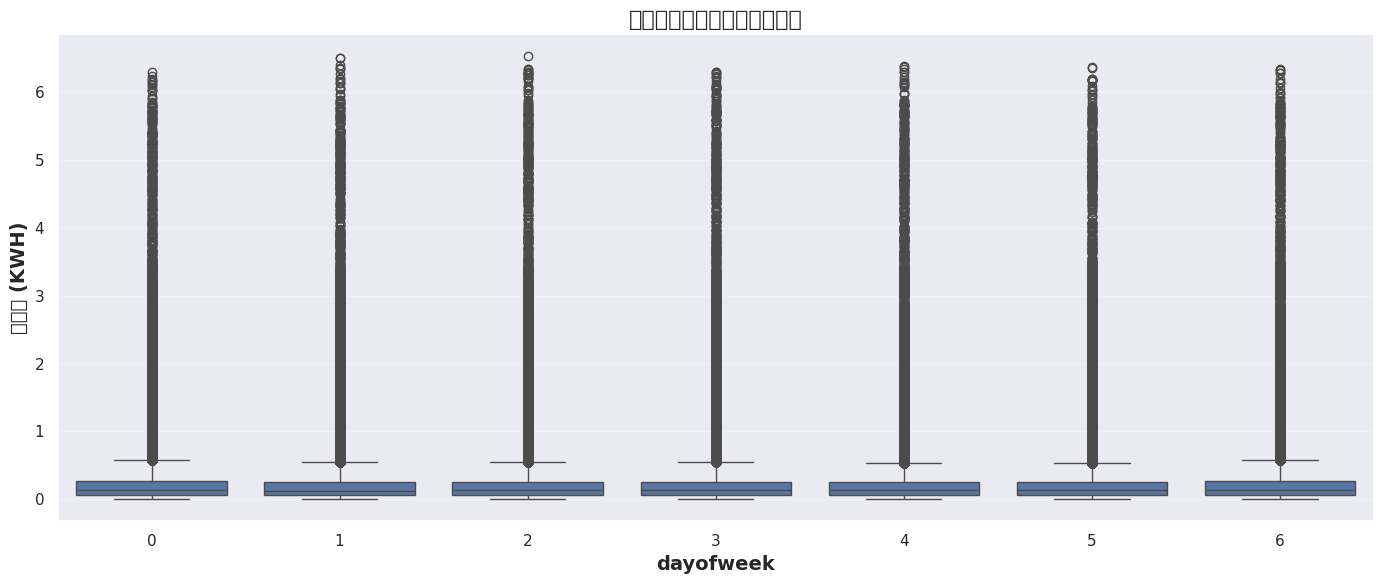

In [21]:
# 按星期几的箱线图
seasonal_box_plot(df, 'kwh', group_by='dayofweek', title='按星期几的用电量分布箱线图')

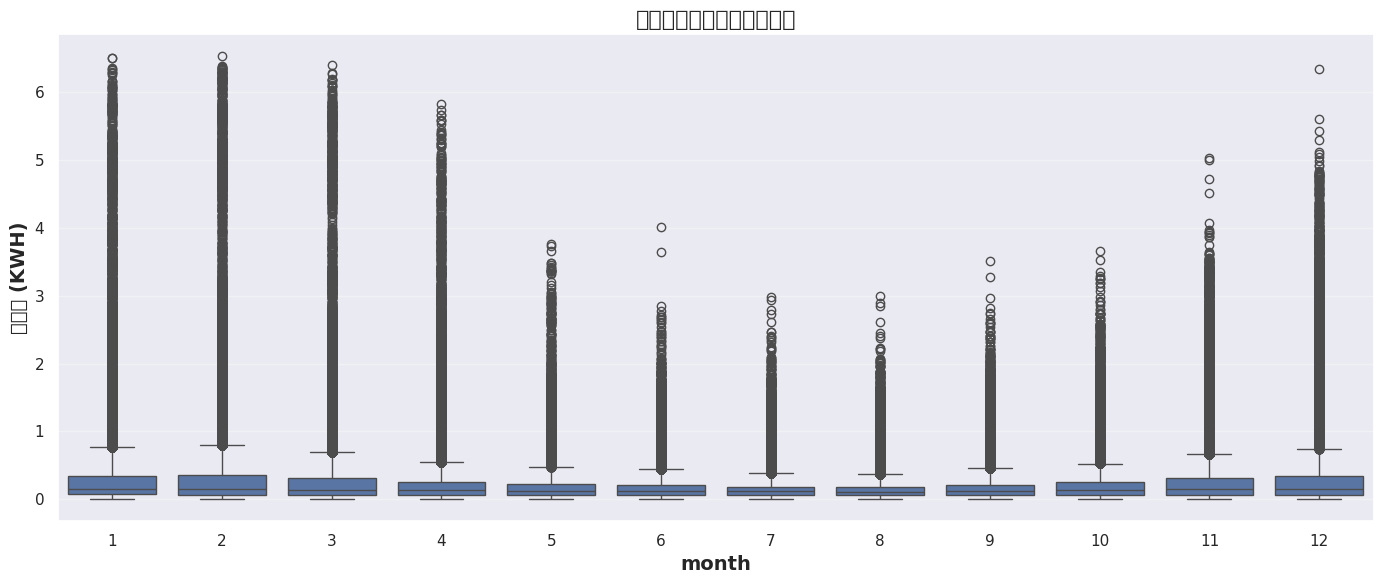

In [22]:
# 按月份的箱线图
seasonal_box_plot(df, 'kwh', group_by='month', title='按月份的用电量分布箱线图')

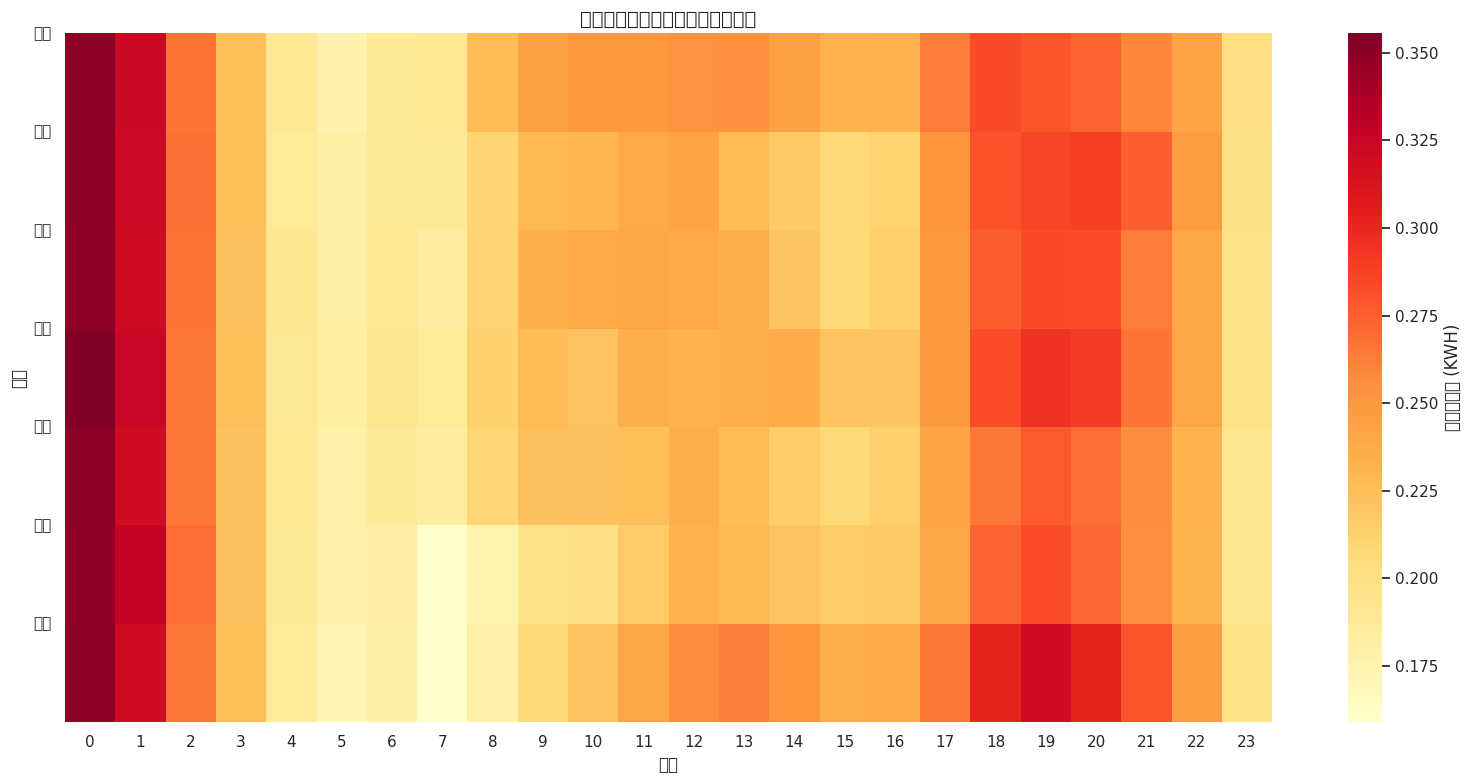

In [23]:
# 热力图：按小时和星期几的平均用电量
hour_day_heatmap = df.groupby(['dayofweek', 'hour'])['kwh'].mean().unstack()

plt.figure(figsize=(16, 8))
sns.heatmap(hour_day_heatmap, annot=False, fmt='.2f', cmap='YlOrRd', 
            cbar_kws={'label': '平均用电量 (KWH)'})
plt.xlabel('小时', fontsize=12, fontweight='bold')
plt.ylabel('星期', fontsize=12, fontweight='bold')
plt.title('按星期和小时的平均用电量热力图', fontsize=14, fontweight='bold')
plt.yticks(range(7), day_names, rotation=0)
plt.tight_layout()
plt.show()

### 客户用电模式对比分析

In [24]:
# 选择几个代表性客户进行对比
top_customers = df['customer_id'].value_counts().head(10).index.tolist()
print(f"选择前10个数据量最多的客户进行对比分析")
print(f"客户ID: {top_customers}")

选择前10个数据量最多的客户进行对比分析
客户ID: ['MAC000018', 'MAC000020', 'MAC000021', 'MAC000022', 'MAC000033', 'MAC000019', 'MAC000034', 'MAC000023', 'MAC000032', 'MAC000027']


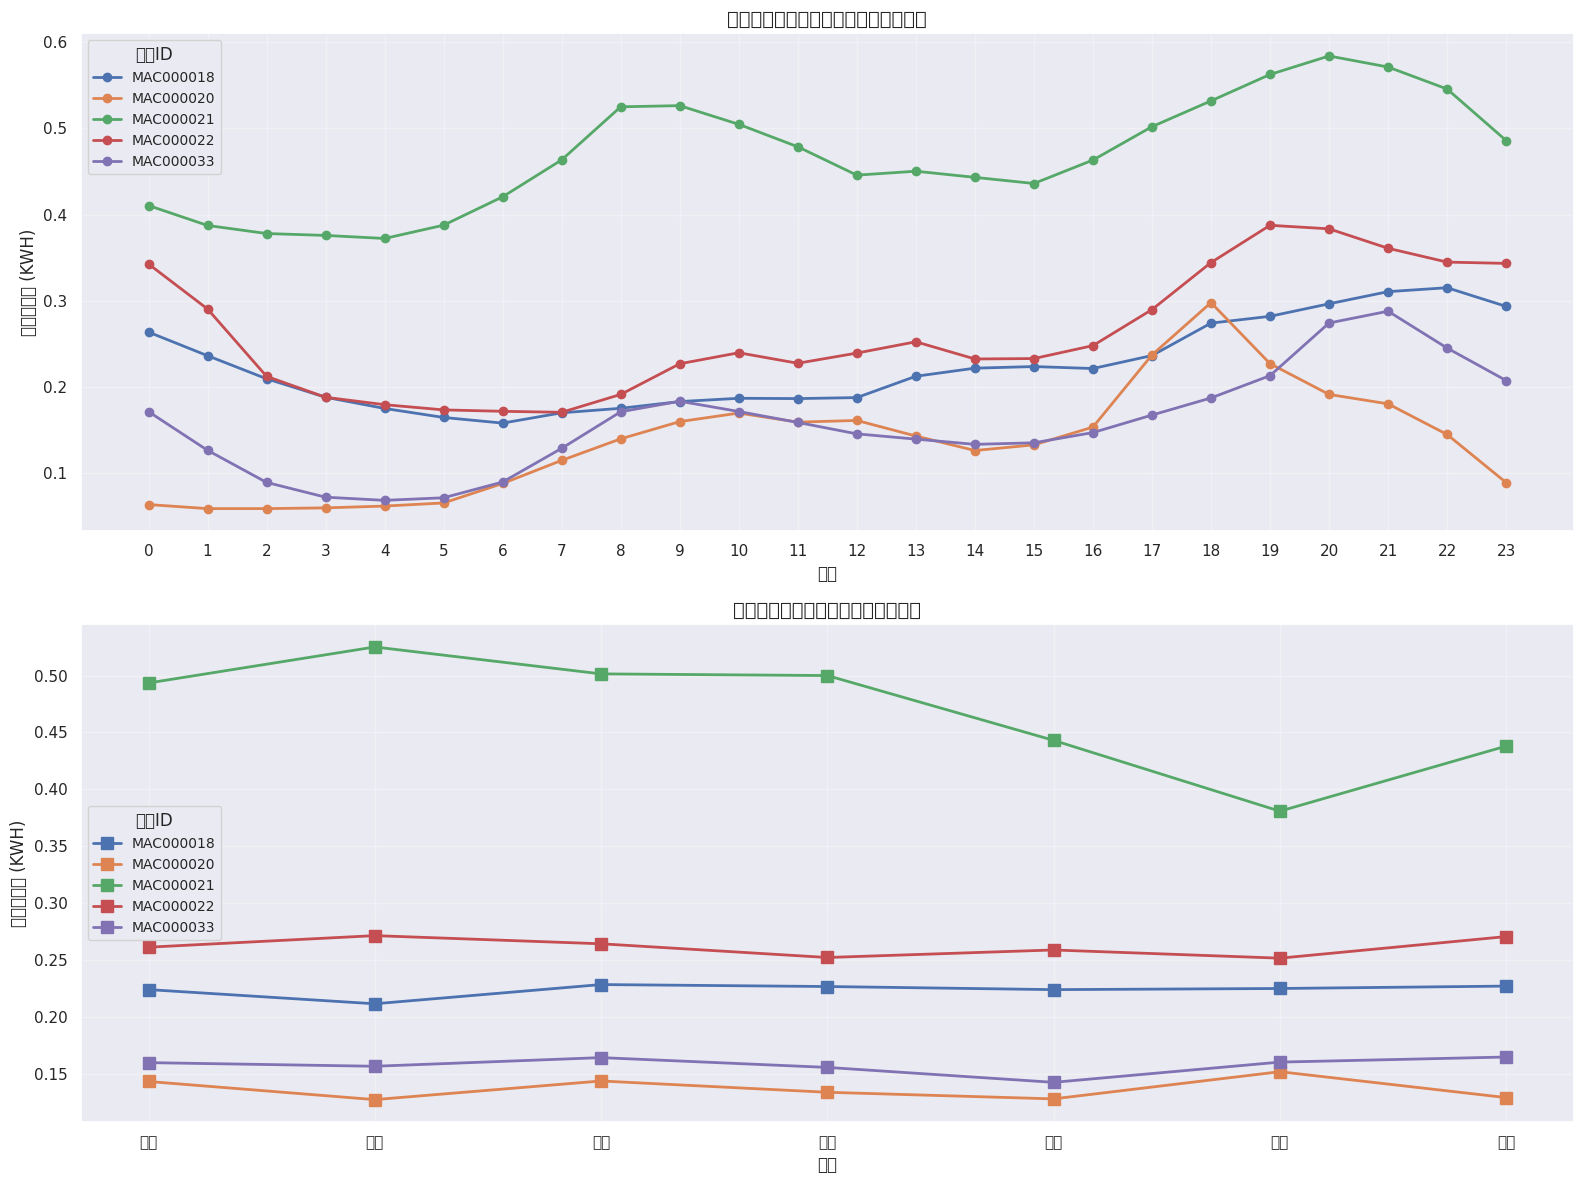

In [25]:
# 对比不同客户的每小时平均用电量模式
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# 选择前5个客户
sample_customers = top_customers[:5]

# 1. 按小时的模式对比
hourly_patterns = df[df['customer_id'].isin(sample_customers)].groupby(['customer_id', 'hour'])['kwh'].mean().unstack()

axes[0].plot(hourly_patterns.T, marker='o', linewidth=2, markersize=6)
axes[0].set_xlabel('小时', fontsize=12)
axes[0].set_ylabel('平均用电量 (KWH)', fontsize=12)
axes[0].set_title('不同客户的每小时平均用电量模式对比', fontsize=14, fontweight='bold')
axes[0].legend(hourly_patterns.index, title='客户ID', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(24))

# 2. 按星期几的模式对比
weekly_patterns = df[df['customer_id'].isin(sample_customers)].groupby(['customer_id', 'dayofweek'])['kwh'].mean().unstack()

axes[1].plot(weekly_patterns.T, marker='s', linewidth=2, markersize=8)
axes[1].set_xlabel('星期', fontsize=12)
axes[1].set_ylabel('平均用电量 (KWH)', fontsize=12)
axes[1].set_title('不同客户的每周平均用电量模式对比', fontsize=14, fontweight='bold')
axes[1].legend(weekly_patterns.index, title='客户ID', fontsize=10)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# 客户用电量统计汇总
print("按客户统计用电量（最小值、最大值、平均值、中位数）:")
customer_summary = df.groupby('customer_id')['kwh'].agg(['min', 'max', 'mean', 'median', 'std', 'count'])
print(customer_summary.head(10))
print(f"\n整体统计:")
print(customer_summary.describe())

按客户统计用电量（最小值、最大值、平均值、中位数）:
               min    max      mean  median       std  count
customer_id                                                 
MAC000002    0.000  2.994  0.252562   0.158  0.247123  24157
MAC000003    0.007  3.921  0.397666   0.166  0.615261  35468
MAC000004    0.000  1.065  0.035383   0.000  0.073146  31676
MAC000006    0.000  0.801  0.059471   0.048  0.052552  36460
MAC000007    0.015  3.784  0.197805   0.115  0.234341  25045
MAC000008    0.000  3.581  0.363102   0.296  0.241687  26012
MAC000009    0.027  2.435  0.178903   0.136  0.169752  25237
MAC000010    0.113  4.189  0.550394   0.410  0.430959  25048
MAC000011    0.040  2.582  0.314299   0.228  0.262185  23704
MAC000012    0.000  1.345  0.044057   0.029  0.080188  24669

整体统计:
             min        max       mean     median        std         count
count  30.000000  30.000000  30.000000  30.000000  30.000000     30.000000
mean    0.025300   2.557733   0.232047   0.145867   0.253349  33332.366667
std     0

In [27]:
# 异常值检测（使用IQR方法）
def detect_outliers_iqr(df, column='kwh'):
    """使用IQR方法检测异常值"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

outliers, lower_bound, upper_bound = detect_outliers_iqr(df)
print(f"异常值检测结果（IQR方法）:")
print(f"下界: {lower_bound:.4f}")
print(f"上界: {upper_bound:.4f}")
print(f"异常值数量: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")
print(f"\n异常值统计:")
print(outliers['kwh'].describe())

异常值检测结果（IQR方法）:
下界: -0.2325
上界: 0.5475
异常值数量: 91,859 (9.19%)

异常值统计:
count    91859.000000
mean         1.132803
std          0.775105
min          0.548000
25%          0.665000
50%          0.876000
75%          1.294000
max          6.528000
Name: kwh, dtype: float64


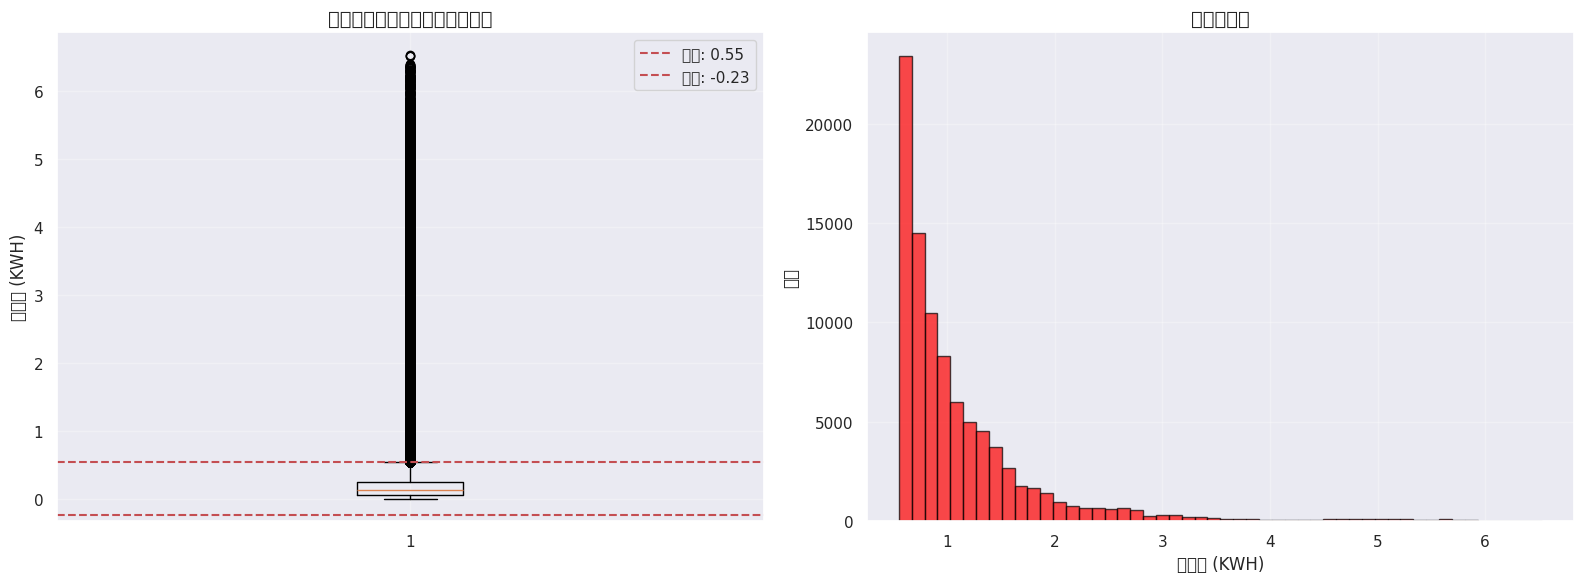

In [28]:
# 可视化异常值
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. 箱线图显示异常值
axes[0].boxplot(df['kwh'].dropna(), vert=True)
axes[0].axhline(y=upper_bound, color='r', linestyle='--', label=f'上界: {upper_bound:.2f}')
axes[0].axhline(y=lower_bound, color='r', linestyle='--', label=f'下界: {lower_bound:.2f}')
axes[0].set_ylabel('用电量 (KWH)', fontsize=12)
axes[0].set_title('用电量箱线图（含异常值标记）', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. 异常值分布
axes[1].hist(outliers['kwh'], bins=50, edgecolor='black', alpha=0.7, color='red')
axes[1].set_xlabel('用电量 (KWH)', fontsize=12)
axes[1].set_ylabel('频数', fontsize=12)
axes[1].set_title('异常值分布', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

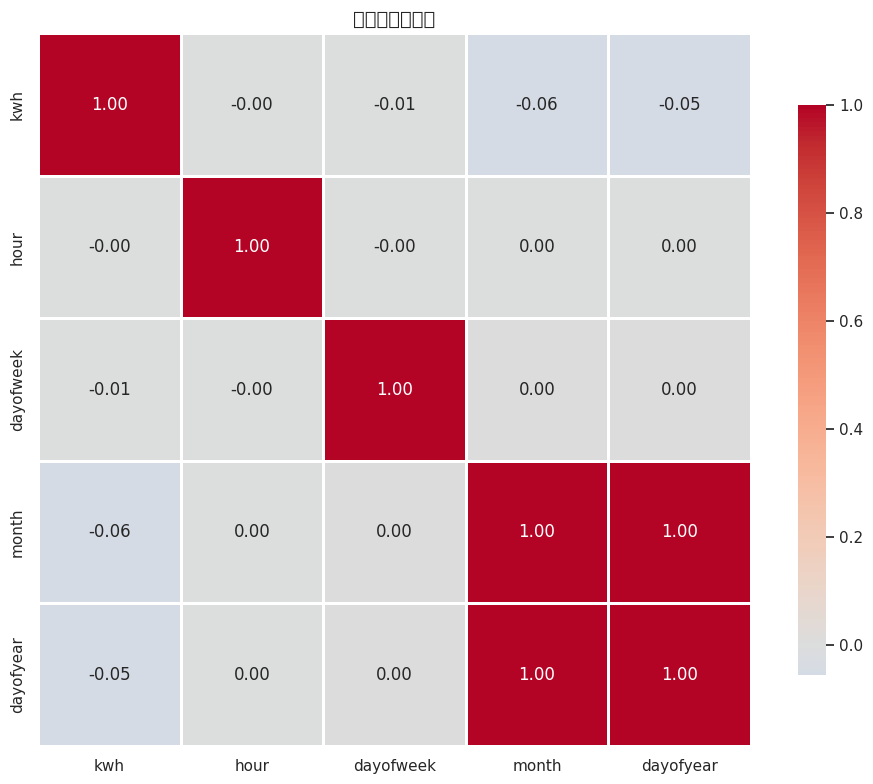

特征相关性矩阵:
                kwh      hour  dayofweek     month  dayofyear
kwh        1.000000 -0.001841  -0.005170 -0.055071  -0.054931
hour      -0.001841  1.000000  -0.000480  0.000652   0.000553
dayofweek -0.005170 -0.000480   1.000000  0.004812   0.004299
month     -0.055071  0.000652   0.004812  1.000000   0.996905
dayofyear -0.054931  0.000553   0.004299  0.996905   1.000000


In [29]:
# 相关性分析（数值特征）
numeric_features = ['kwh', 'hour', 'dayofweek', 'month', 'dayofyear']
correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('特征相关性矩阵', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("特征相关性矩阵:")
print(correlation_matrix)

### 数据质量检查与总结


In [30]:
# 数据质量总结
print("=" * 60)
print("数据质量检查总结")
print("=" * 60)

print(f"\n1. 数据规模:")
print(f"   - 总记录数: {len(df):,}")
print(f"   - 唯一客户数: {df['customer_id'].nunique()}")
print(f"   - 时间跨度: {df['datetime'].max() - df['datetime'].min()}")

print(f"\n2. 缺失值:")
missing = df.isnull().sum()
print(f"   - 总缺失值: {missing.sum():,}")
for col, count in missing[missing > 0].items():
    print(f"   - {col}: {count:,} ({count/len(df)*100:.2f}%)")

print(f"\n3. 数据完整性:")
print(f"   - 零值数量: {(df['kwh'] == 0).sum():,} ({(df['kwh'] == 0).sum()/len(df)*100:.2f}%)")
print(f"   - 负值数量: {(df['kwh'] < 0).sum():,}")

print(f"\n4. 时间序列完整性:")
# 检查每个客户的时间序列是否连续
print(f"   - 时间范围: {df['datetime'].min()} 到 {df['datetime'].max()}")
expected_records_per_customer = (df['datetime'].max() - df['datetime'].min()).total_seconds() / 1800  # 每半小时一条
print(f"   - 预期每条时间序列记录数: ~{expected_records_per_customer:.0f}")
print(f"   - 实际平均记录数: {df.groupby('customer_id').size().mean():.0f}")

print(f"\n5. 用电量统计:")
print(f"   - 最小值: {df['kwh'].min():.4f} KWH")
print(f"   - 最大值: {df['kwh'].max():.4f} KWH")
print(f"   - 平均值: {df['kwh'].mean():.4f} KWH")
print(f"   - 中位数: {df['kwh'].median():.4f} KWH")
print(f"   - 标准差: {df['kwh'].std():.4f} KWH")

print(f"\n6. 异常值:")
print(f"   - 异常值数量: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")
print(f"   - 异常值范围: {outliers['kwh'].min():.4f} - {outliers['kwh'].max():.4f} KWH")

print("\n" + "=" * 60)


数据质量检查总结

1. 数据规模:
   - 总记录数: 1,000,000
   - 唯一客户数: 30
   - 时间跨度: 814 days 11:00:00

2. 缺失值:
   - 总缺失值: 29
   - kwh: 29 (0.00%)

3. 数据完整性:
   - 零值数量: 45,538 (4.55%)
   - 负值数量: 0

4. 时间序列完整性:
   - 时间范围: 2011-12-06 13:00:00 到 2014-02-28 00:00:00
   - 预期每条时间序列记录数: ~39094
   - 实际平均记录数: 33333

5. 用电量统计:
   - 最小值: 0.0000 KWH
   - 最大值: 6.5280 KWH
   - 平均值: 0.2396 KWH
   - 中位数: 0.1290 KWH
   - 标准差: 0.3875 KWH

6. 异常值:
   - 异常值数量: 91,859 (9.19%)
   - 异常值范围: 0.5480 - 6.5280 KWH



### 月度用电量趋势分析


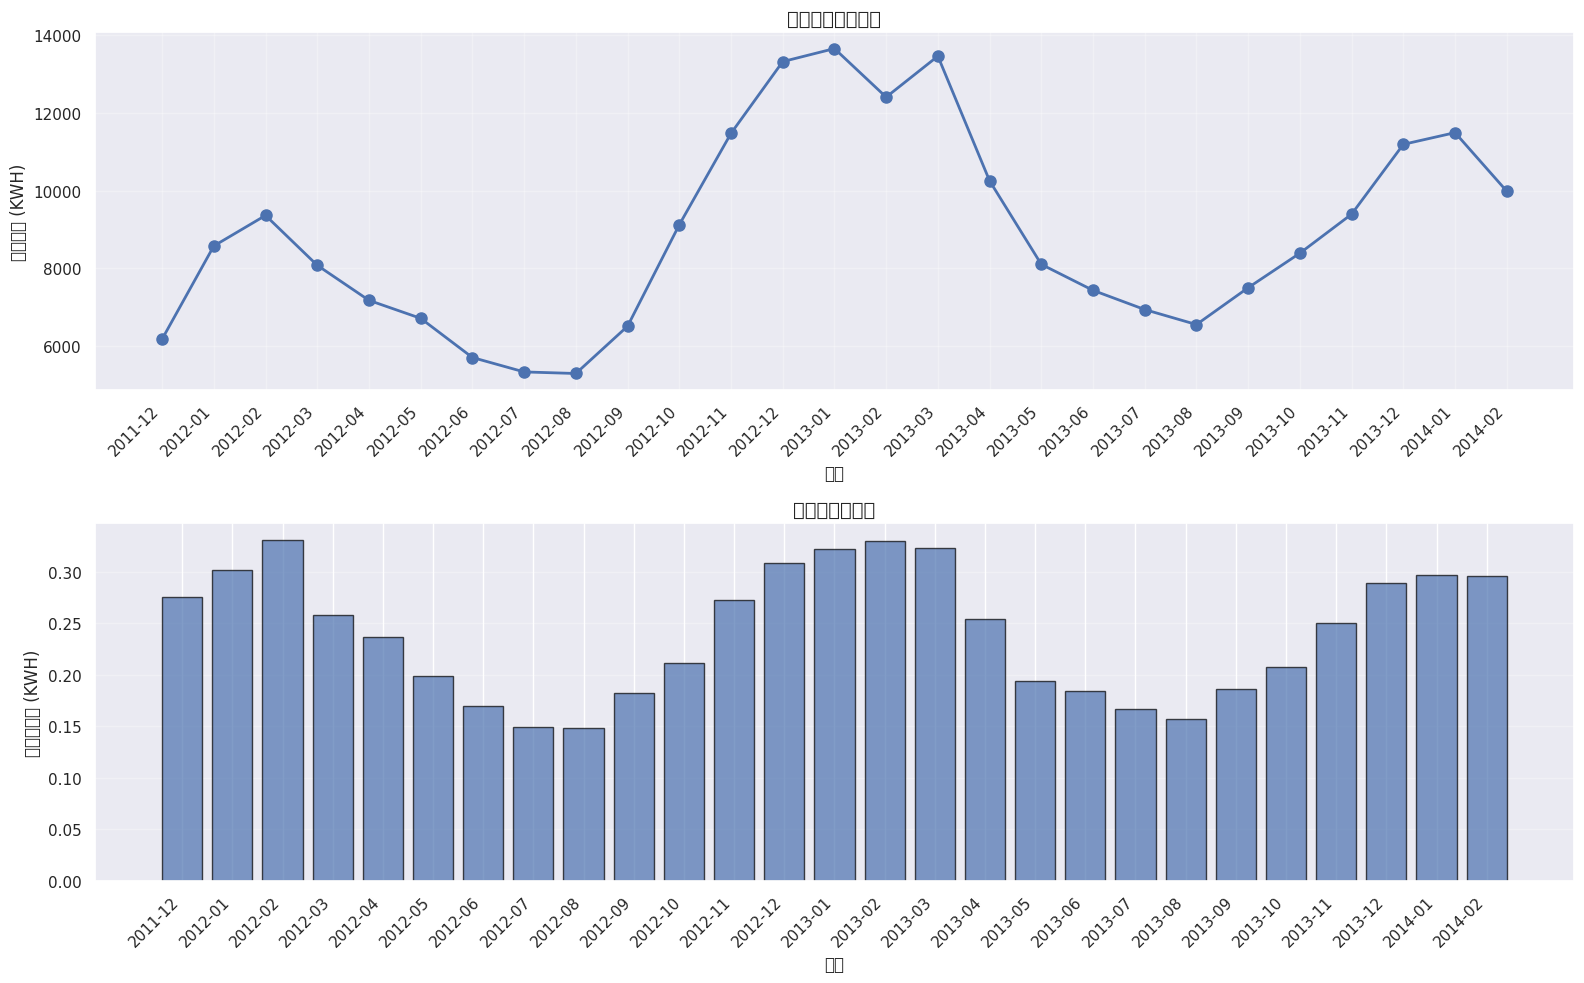

月度用电量统计:
    year  month           sum      mean  count year_month
0   2011     12   6173.915999  0.275437  22415    2011-12
1   2012      1   8574.768997  0.302322  28363    2012-01
2   2012      2   9361.657997  0.330684  28310    2012-02
3   2012      3   8075.739000  0.258283  31267    2012-03
4   2012      4   7172.833999  0.237056  30258    2012-04
5   2012      5   6709.113999  0.199261  33670    2012-05
6   2012      6   5699.814002  0.170098  33509    2012-06
7   2012      7   5328.305000  0.149348  35677    2012-07
8   2012      8   5287.830000  0.147978  35734    2012-08
9   2012      9   6506.424999  0.182202  35710    2012-09
10  2012     10   9120.873003  0.211936  43036    2012-10
11  2012     11  11476.287001  0.273017  42035    2012-11
12  2012     12  13325.206997  0.308747  43159    2012-12
13  2013      1  13660.983997  0.322117  42410    2013-01
14  2013      2  12410.346000  0.329580  37655    2013-02
15  2013      3  13466.226997  0.323047  41685    2013-03
16  2

In [31]:
# 按月份统计用电量
monthly_consumption = df.groupby(['year', 'month'])['kwh'].agg(['sum', 'mean', 'count']).reset_index()
monthly_consumption['year_month'] = monthly_consumption['year'].astype(str) + '-' + monthly_consumption['month'].astype(str).str.zfill(2)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# 1. 月度总用电量
axes[0].plot(range(len(monthly_consumption)), monthly_consumption['sum'], 
             marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('月份', fontsize=12)
axes[0].set_ylabel('总用电量 (KWH)', fontsize=12)
axes[0].set_title('月度总用电量趋势', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(len(monthly_consumption)))
axes[0].set_xticklabels(monthly_consumption['year_month'], rotation=45, ha='right')
axes[0].grid(True, alpha=0.3)

# 2. 月度平均用电量
axes[1].bar(range(len(monthly_consumption)), monthly_consumption['mean'], 
            alpha=0.7, edgecolor='black')
axes[1].set_xlabel('月份', fontsize=12)
axes[1].set_ylabel('平均用电量 (KWH)', fontsize=12)
axes[1].set_title('月度平均用电量', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(len(monthly_consumption)))
axes[1].set_xticklabels(monthly_consumption['year_month'], rotation=45, ha='right')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("月度用电量统计:")
print(monthly_consumption)


### 客户用电行为聚类分析（基于统计特征）


客户特征统计:
        kwh_mean    kwh_std    kwh_min    kwh_max  kwh_median  peak_hour  \
count  30.000000  30.000000  30.000000  30.000000   30.000000       30.0   
mean    0.232047   0.253349   0.025300   2.557733    0.145867        0.0   
std     0.156590   0.230203   0.032186   1.379922    0.108405        0.0   
min     0.027351   0.052547   0.000000   0.505000    0.000000        0.0   
25%     0.102663   0.110665   0.000000   1.645000    0.065250        0.0   
50%     0.210829   0.204388   0.015500   2.450000    0.134500        0.0   
75%     0.310390   0.288993   0.028500   3.309500    0.165250        0.0   
max     0.566821   1.140982   0.113000   6.528000    0.410000        0.0   

       kwh_range     kwh_cv  
count  30.000000  30.000000  
mean    2.532433   1.159495  
std     1.371550   0.519719  
min     0.482000   0.487863  
25%     1.635500   0.775777  
50%     2.422000   0.986682  
75%     3.292500   1.518795  
max     6.505000   2.285640  


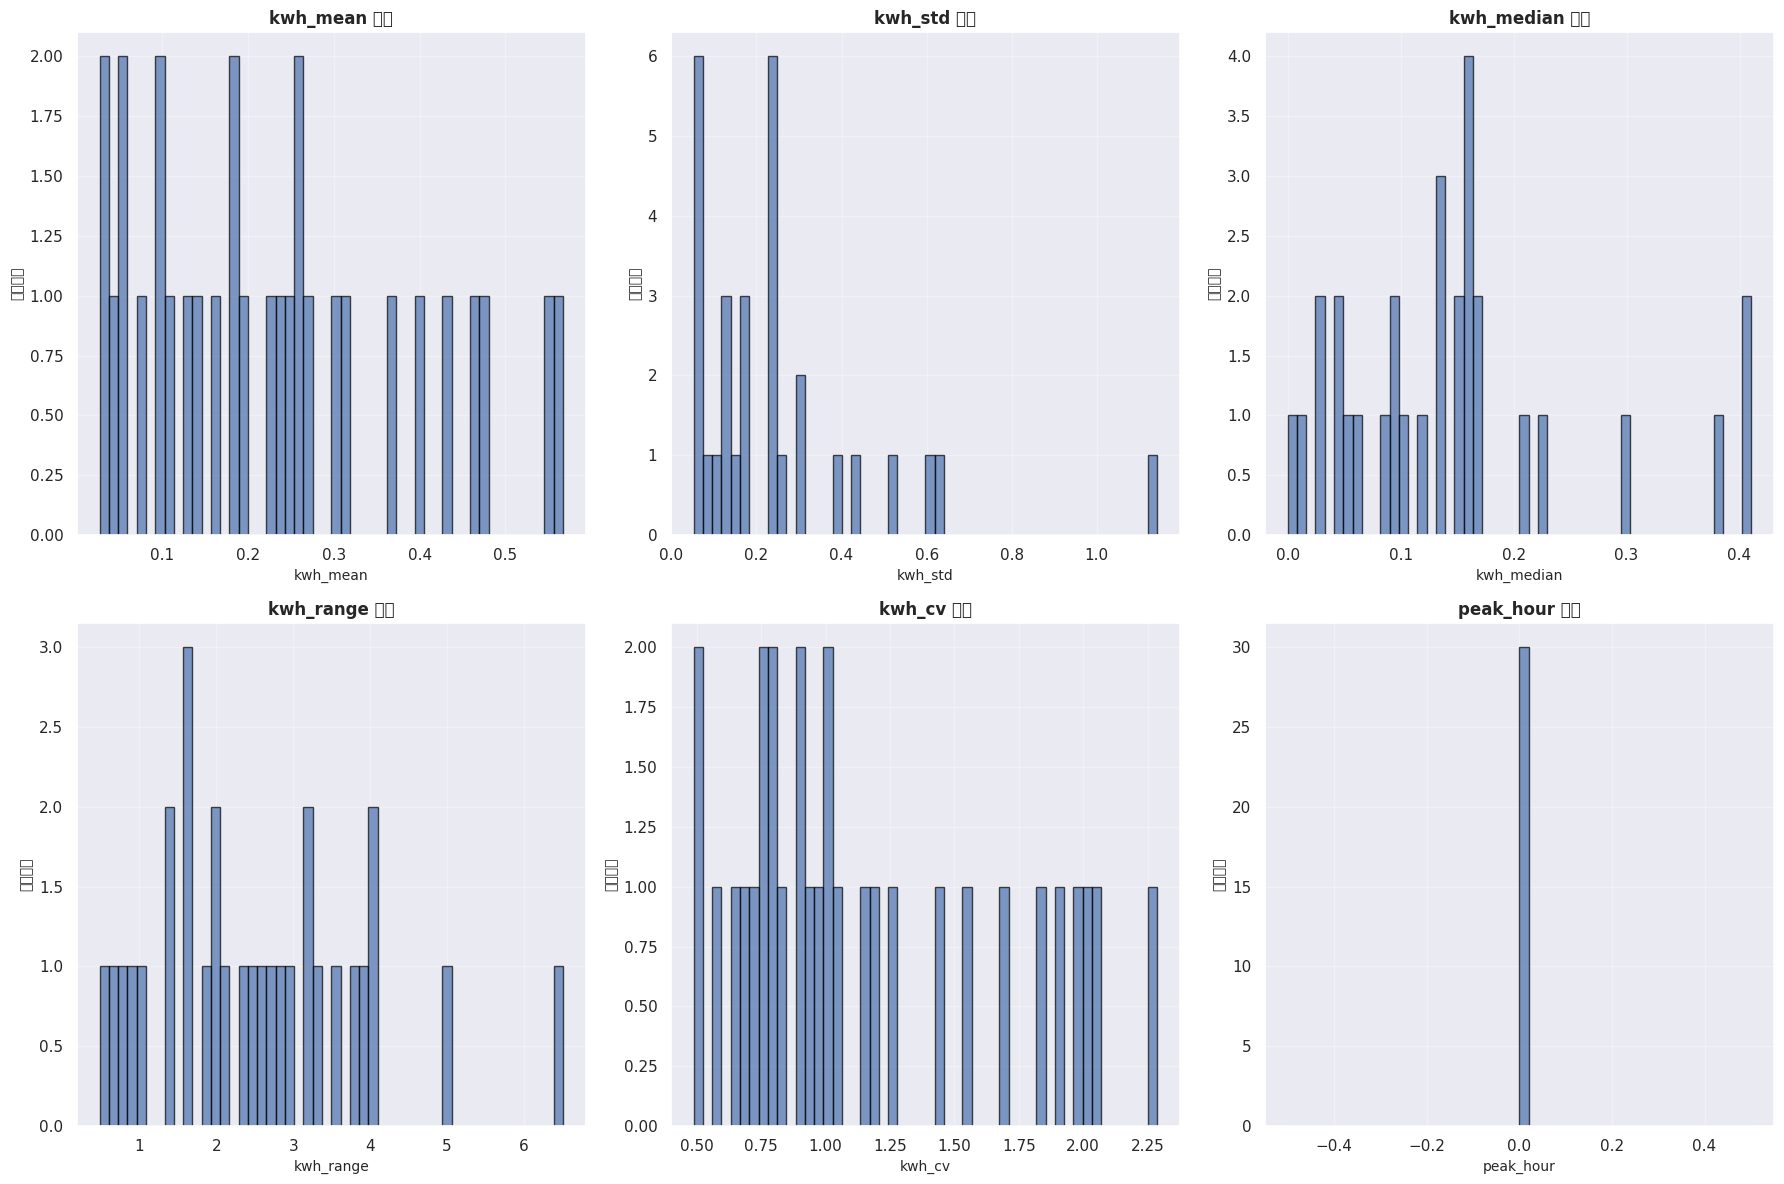

In [32]:
# 为每个客户计算统计特征
customer_features = df.groupby('customer_id').agg({
    'kwh': ['mean', 'std', 'min', 'max', 'median'],
    'hour': lambda x: x.mode()[0] if len(x.mode()) > 0 else 0  # 最常出现的小时
}).reset_index()

# 展平列名
customer_features.columns = ['customer_id', 'kwh_mean', 'kwh_std', 'kwh_min', 'kwh_max', 'kwh_median', 'peak_hour']

# 添加更多特征
customer_features['kwh_range'] = customer_features['kwh_max'] - customer_features['kwh_min']
customer_features['kwh_cv'] = customer_features['kwh_std'] / customer_features['kwh_mean']  # 变异系数

print("客户特征统计:")
print(customer_features.describe())

# 可视化客户特征分布
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

features_to_plot = ['kwh_mean', 'kwh_std', 'kwh_median', 'kwh_range', 'kwh_cv', 'peak_hour']
for idx, feature in enumerate(features_to_plot):
    row = idx // 3
    col = idx % 3
    axes[row, col].hist(customer_features[feature].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[row, col].set_xlabel(feature, fontsize=10)
    axes[row, col].set_ylabel('客户数量', fontsize=10)
    axes[row, col].set_title(f'{feature} 分布', fontsize=12, fontweight='bold')
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 总结与建议


In [33]:
print("=" * 60)
print("EDA 分析总结与建议")
print("=" * 60)

print("\n【数据集特点】")
print("1. 这是一个多客户的时间序列电力消耗数据集")
print("2. 数据采集频率为每半小时一次")
print("3. 包含多个客户（LCLid）的用电量记录")

print("\n【主要发现】")
print("1. 用电量存在明显的日内模式（按小时变化）")
print("2. 用电量存在周模式（工作日vs周末）")
print("3. 不同客户的用电模式存在显著差异")
print("4. 数据中存在异常值，需要进一步处理")

print("\n【数据预处理建议】")
print("1. 处理缺失值（如果有）")
print("2. 处理异常值（使用IQR方法或领域知识）")
print("3. 处理零值和负值（根据业务逻辑决定）")
print("4. 确保时间序列的连续性（填充缺失时间点）")
print("5. 特征工程：创建滞后特征、移动平均特征等")

print("\n【建模建议】")
print("1. 考虑使用时间序列模型（LSTM, GRU, Transformer等）")
print("2. 可以利用客户特征进行个性化建模")
print("3. 考虑联邦学习场景，每个客户作为独立的参与方")
print("4. 特征选择：时间特征（小时、星期、月份）+ 历史用电量特征")

print("\n" + "=" * 60)


EDA 分析总结与建议

【数据集特点】
1. 这是一个多客户的时间序列电力消耗数据集
2. 数据采集频率为每半小时一次
3. 包含多个客户（LCLid）的用电量记录

【主要发现】
1. 用电量存在明显的日内模式（按小时变化）
2. 用电量存在周模式（工作日vs周末）
3. 不同客户的用电模式存在显著差异
4. 数据中存在异常值，需要进一步处理

【数据预处理建议】
1. 处理缺失值（如果有）
2. 处理异常值（使用IQR方法或领域知识）
3. 处理零值和负值（根据业务逻辑决定）
4. 确保时间序列的连续性（填充缺失时间点）
5. 特征工程：创建滞后特征、移动平均特征等

【建模建议】
1. 考虑使用时间序列模型（LSTM, GRU, Transformer等）
2. 可以利用客户特征进行个性化建模
3. 考虑联邦学习场景，每个客户作为独立的参与方
4. 特征选择：时间特征（小时、星期、月份）+ 历史用电量特征

